# CLT-BRASIL — Emprego Formal no Brasil
## Análise de Série Temporal e Previsão do Saldo do Novo CAGED (MTE)

**Objetivo.** Recuperar, tratar e modelar a série mensal do **saldo de empregos formais
(celetistas / CLT)** no Brasil e em cada Unidade da Federação, a partir dos microdados do
**Novo CAGED** do Ministério do Trabalho e Emprego (MTE), e projetar a continuação da série
**até junho de 2027** com intervalos de confiança e índices estatísticos.

**Fonte dos dados.** PDET/MTE — microdados do *Novo CAGED* (`ftp.mtps.gov.br`,
arquivos `CAGEDMOV<AAAAMM>.7z`). O **saldo** de cada competência/UF é
`Σ(saldomovimentação)`, em que cada admissão conta `+1` e cada desligamento `-1`.
Essa agregação reproduz exatamente a série oficial *"Novo CAGED sem ajuste"*
(validado contra o IPEADATA: jun/2025 = 166.621 em ambas as fontes).

**Roteiro.**
1. Carregamento dos dados · 2. Qualidade e limpeza · 3. EDA nacional ·
4. Decomposição e sazonalidade · 5. Estacionariedade · 6. Heterocedasticidade ·
7. Panorama por estado e região · 8. Modelagem e previsão (SARIMA, ETS, Seasonal Naive) ·
9. Métricas e seleção · 10. Relatório HTML autocontido.


In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": .3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})
BLUE, RED, GREEN = "#2563eb", "#dc2626", "#16a34a"

import clt
print("Módulo de análise carregado. Horizonte de previsão:", clt.HORIZON_END)

Módulo de análise carregado. Horizonte de previsão: 2027-06-01


## 1. Carregamento dos dados

Carregamos (i) o **painel longo** `date × UF × saldo` (apenas as 27 UFs válidas) e
(ii) a **série nacional** agregada. A frequência é mensal (`MS` = início de mês).

In [2]:
panel = clt.load_panel()
brasil = clt.load_brasil()
print("Painel:", panel.shape, "| período:",
      panel['date'].min().date(), "→", panel['date'].max().date())
print("UFs:", panel['uf'].nunique(), "| Série Brasil:", len(brasil), "meses")
panel.head()

Painel: (2025, 5) | período: 2020-01-01 → 2026-03-01
UFs: 27 | Série Brasil: 75 meses


,date,uf_code,uf,regiao,saldo
0,2020-01-01,12,AC,Norte,130
1,2020-02-01,12,AC,Norte,857
2,2020-03-01,12,AC,Norte,56
3,2020-04-01,12,AC,Norte,-284
4,2020-05-01,12,AC,Norte,106


## 2. Qualidade e limpeza dos dados

Verificamos: códigos de UF inesperados nos microdados, continuidade temporal
(sem meses faltantes), tipos e estatísticas descritivas. Os microdados trazem um
**28º código de UF** além das 27 oficiais — investigamos e o excluímos do agregado.

In [3]:
raw = pd.read_csv(os.path.join(clt.RAW, "caged_uf_panel.csv"), parse_dates=["date"])
print("Códigos de UF presentes no arquivo bruto:")
print(raw[['uf_code','uf']].drop_duplicates().sort_values('uf_code').to_string(index=False))
extra = raw[~raw['uf'].isin(clt.UF_NOME)]
print("\nRegistros fora das 27 UFs (ex.: código '99'/não identificado):",
      extra['uf'].unique(), "| participação no saldo:",
      f"{extra['saldo'].sum() / raw['saldo'].sum() * 100:.3f}%")

Códigos de UF presentes no arquivo bruto:
 uf_code   uf
      11   RO
      12   AC
      13   AM
      14   RR
      15   PA
      16   AP
      17   TO
      21   MA
      22   PI
      23   CE
      24   RN
      25   PB
      26   PE
      27   AL
      28   SE
      29   BA
      31   MG
      32   ES
      33   RJ
      35   SP
      41   PR
      42   SC
      43   RS
      50   MS
      51   MT
      52   GO
      53   DF
      99 ND99

Registros fora das 27 UFs (ex.: código '99'/não identificado): ['ND99'] | participação no saldo: 0.363%


In [4]:
# continuidade temporal e integridade
idx_full = pd.date_range(brasil.index.min(), brasil.index.max(), freq="MS")
faltantes = idx_full.difference(brasil.index)
print("Meses faltantes na série nacional:", list(faltantes) or "nenhum")
print("Valores nulos:", int(brasil.isna().sum()))
display(brasil.describe().round(0).to_frame("Saldo Brasil"))

Meses faltantes na série nacional: nenhum
Valores nulos: 0


,Saldo Brasil
count,75.0
mean,133417.0
std,238592.0
min,-902317.0
25%,123620.0
50%,183762.0
75%,256202.0
max,431911.0


## 3. Análise exploratória — Brasil

Visão geral do saldo nacional: nível mensal, média móvel de 12 meses e o
**estoque acumulado** (soma cumulativa do saldo, *proxy* do estoque de vínculos gerados
desde jan/2020). O choque da pandemia (mar–abr/2020) é o evento dominante da série.

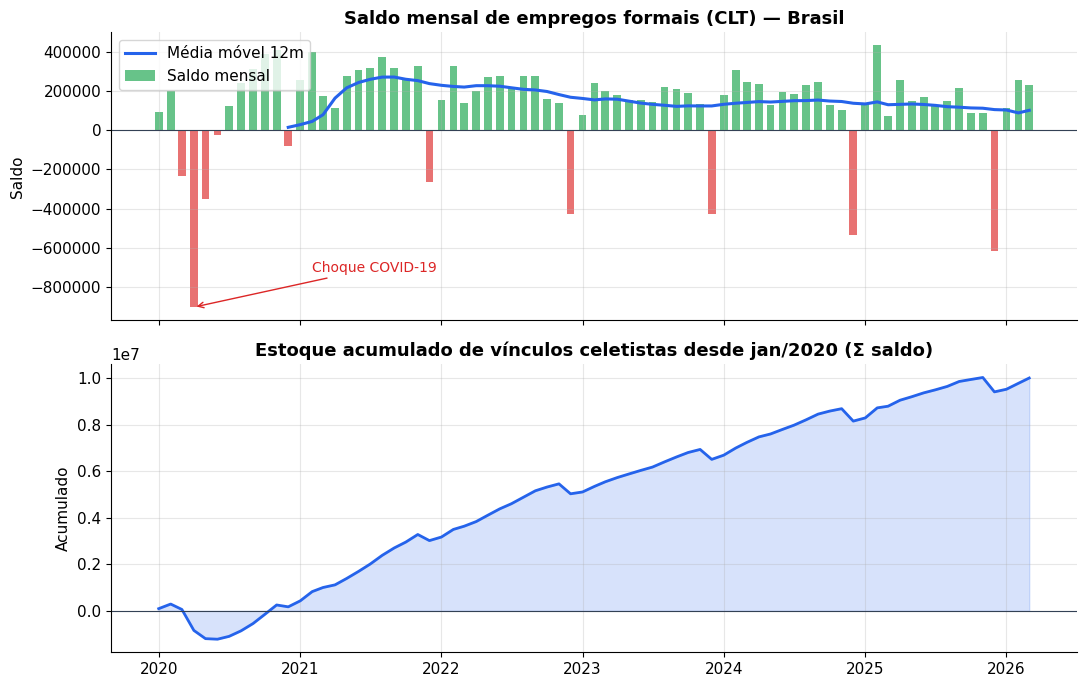

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].bar(brasil.index, brasil.values, width=20,
          color=[GREEN if v>=0 else RED for v in brasil.values], alpha=.65, label="Saldo mensal")
ax[0].plot(brasil.index, brasil.rolling(12).mean(), color=BLUE, lw=2.2, label="Média móvel 12m")
ax[0].axhline(0, color="#334155", lw=.8)
ax[0].set_title("Saldo mensal de empregos formais (CLT) — Brasil")
ax[0].legend(loc="upper left"); ax[0].set_ylabel("Saldo")
ax[0].annotate("Choque COVID-19", xy=(pd.Timestamp("2020-04-01"), brasil.min()),
               xytext=(pd.Timestamp("2021-02-01"), brasil.min()*.8),
               arrowprops=dict(arrowstyle="->", color=RED), color=RED, fontsize=10)

ax[1].fill_between(brasil.index, brasil.cumsum(), color=BLUE, alpha=.18)
ax[1].plot(brasil.index, brasil.cumsum(), color=BLUE, lw=2)
ax[1].set_title("Estoque acumulado de vínculos celetistas desde jan/2020 (Σ saldo)")
ax[1].set_ylabel("Acumulado"); ax[1].axhline(0, color="#334155", lw=.8)
plt.tight_layout(); plt.show()

## 4. Decomposição e sazonalidade

Decomposição **STL** (robusta) em tendência, sazonalidade e resíduo, seguida da
análise do padrão sazonal mensal e das funções de autocorrelação (ACF/PACF), que
orientam a ordem dos modelos SARIMA.

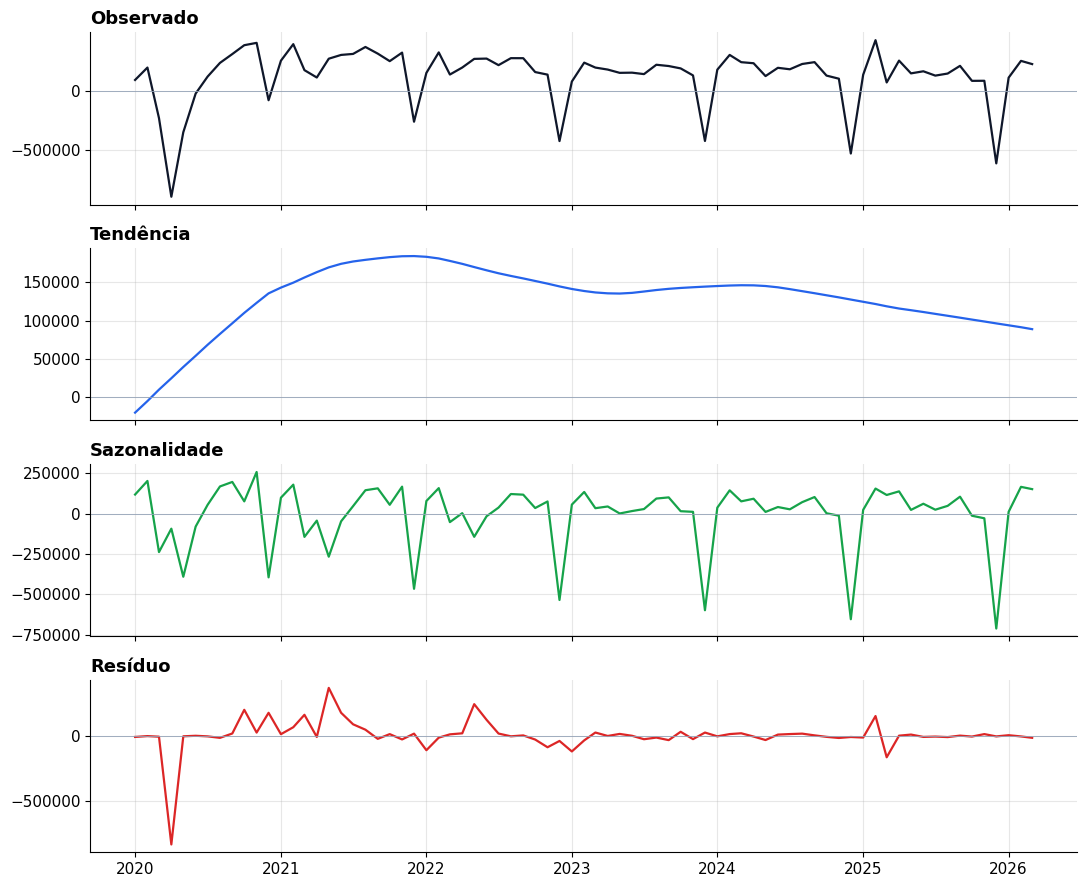

Força da sazonalidade (Hyndman): 0.695


In [6]:
res = clt.stl_decompose(brasil)
fig, ax = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for a, (comp, c, t) in zip(ax, [
        (brasil, "#0f172a", "Observado"), (res.trend, BLUE, "Tendência"),
        (res.seasonal, GREEN, "Sazonalidade"), (res.resid, RED, "Resíduo")]):
    a.plot(comp.index, comp.values, color=c, lw=1.6); a.set_title(t, loc="left")
    a.axhline(0, color="#94a3b8", lw=.6)
plt.tight_layout(); plt.show()
print(f"Força da sazonalidade (Hyndman): {clt.seasonal_strength(brasil):.3f}")

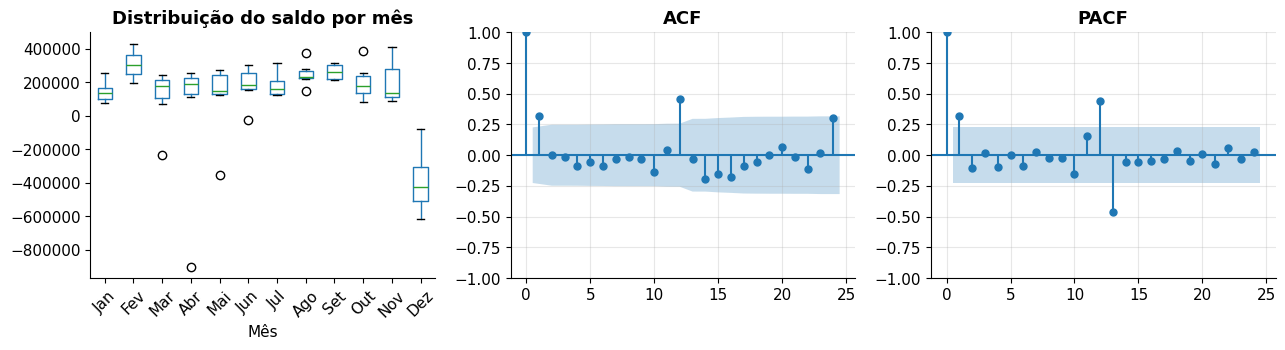

In [7]:
# padrão sazonal por mês e correlogramas
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
dfm = brasil.to_frame("saldo"); dfm["mes"] = dfm.index.month
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
dfm.boxplot(column="saldo", by="mes", ax=ax[0], grid=False)
ax[0].set_title("Distribuição do saldo por mês"); ax[0].set_xlabel("Mês"); ax[0].set_xticklabels(meses, rotation=45)
plt.suptitle("")
plot_acf(brasil.dropna(), lags=24, ax=ax[1], title="ACF")
plot_pacf(brasil.dropna(), lags=24, ax=ax[2], title="PACF", method="ywm")
plt.tight_layout(); plt.show()

## 5. Estacionariedade

Testes **ADF** (H0: raiz unitária / não estacionária) e **KPSS** (H0: estacionária)
sobre o nível, a 1ª diferença e a diferença sazonal (lag 12). A combinação indica a
ordem de integração regular (d) e sazonal (D).

In [8]:
def resumo_estacionariedade(s, nome):
    adf = clt.adf_test(s); kp = clt.kpss_test(s)
    return {"série": nome, "ADF p": round(adf['pvalue'],4),
            "ADF estac.": adf['stationary'], "KPSS p": round(kp['pvalue'],4),
            "KPSS estac.": kp['stationary']}
tab = pd.DataFrame([
    resumo_estacionariedade(brasil, "nível"),
    resumo_estacionariedade(brasil.diff().dropna(), "1ª diferença"),
    resumo_estacionariedade(brasil.diff(12).dropna(), "diferença sazonal (12)"),
])
display(tab)

C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")
C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


,série,ADF p,ADF estac.,KPSS p,KPSS estac.
0,nível,0.1395,False,0.1000,True
1,1ª diferença,0.0580,False,0.0571,True
2,diferença sazonal (12),0.0284,True,0.1000,True


## 6. Heterocedasticidade

A série de **saldo assume valores negativos**, de modo que transformações log/Box-Cox
não se aplicam ao nível. Avaliamos a variância condicional com o teste **ARCH-LM**
(Engle) e inspecionamos o desvio-padrão móvel. Onde há heterocedasticidade, o componente
de média do SARIMA (via diferenciação) e os intervalos de confiança empíricos a acomodam.

ARCH-LM (12 lags): estatística=47.19, p-valor=0.0000
→ Há evidência de heterocedasticidade condicional.


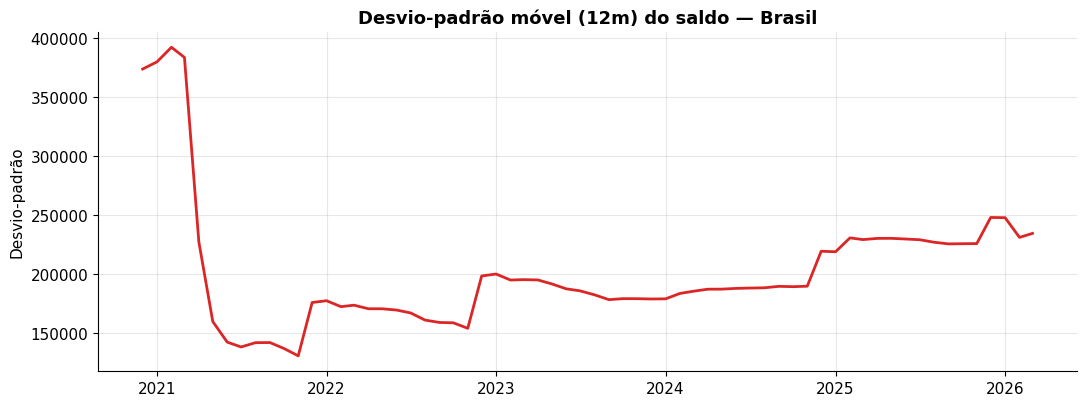

In [9]:
arch = clt.arch_test(brasil)
print(f"ARCH-LM (12 lags): estatística={arch['stat']:.2f}, p-valor={arch['pvalue']:.4f}")
print("→", "Há evidência de heterocedasticidade condicional."
      if arch['heteroscedastic'] else "Sem evidência de heterocedasticidade condicional.")
roll_std = brasil.rolling(12).std()
plt.figure()
plt.plot(roll_std.index, roll_std.values, color=RED, lw=2)
plt.title("Desvio-padrão móvel (12m) do saldo — Brasil"); plt.ylabel("Desvio-padrão")
plt.tight_layout(); plt.show()

## 7. Panorama por estado e região

Distribuição espacial do mercado formal: saldo acumulado em 12 meses por região,
ranking das UFs e **mapa de calor de sazonalidade** (saldo médio por mês × UF).

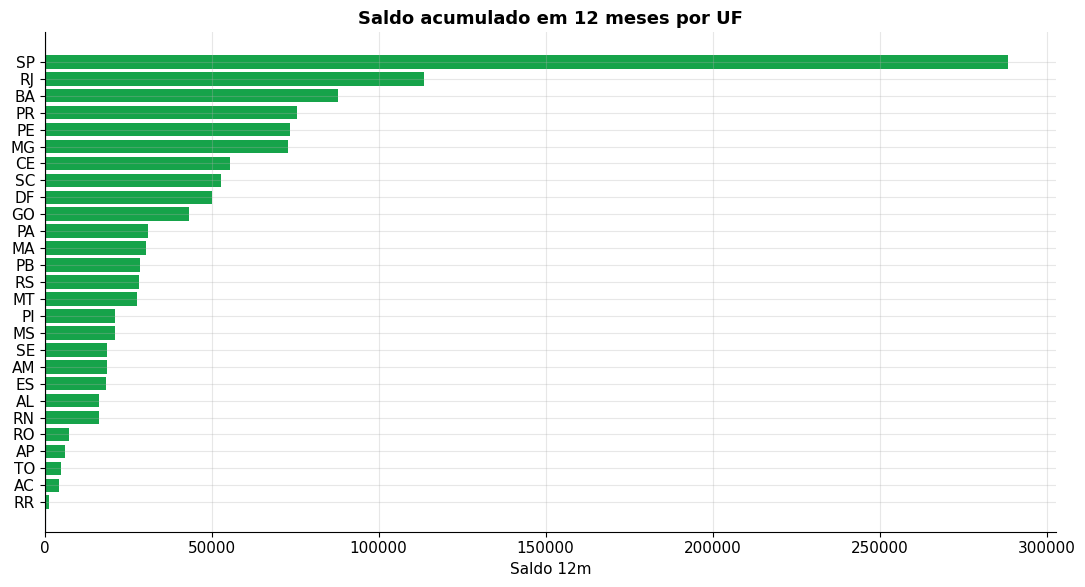

In [10]:
ufs = clt.all_series(panel)  # dict nome->série (Brasil + 27 UFs)
ordem = [u for r in clt.REGIOES.values() for u in r]

# ranking saldo acumulado 12m
acc12 = pd.Series({u: ufs[u].iloc[-12:].sum() for u in ordem}).sort_values()
plt.figure(figsize=(11, 6))
plt.barh(acc12.index, acc12.values, color=[GREEN if v>=0 else RED for v in acc12.values])
plt.title("Saldo acumulado em 12 meses por UF"); plt.xlabel("Saldo 12m"); plt.axvline(0,color="#334155",lw=.8)
plt.tight_layout(); plt.show()

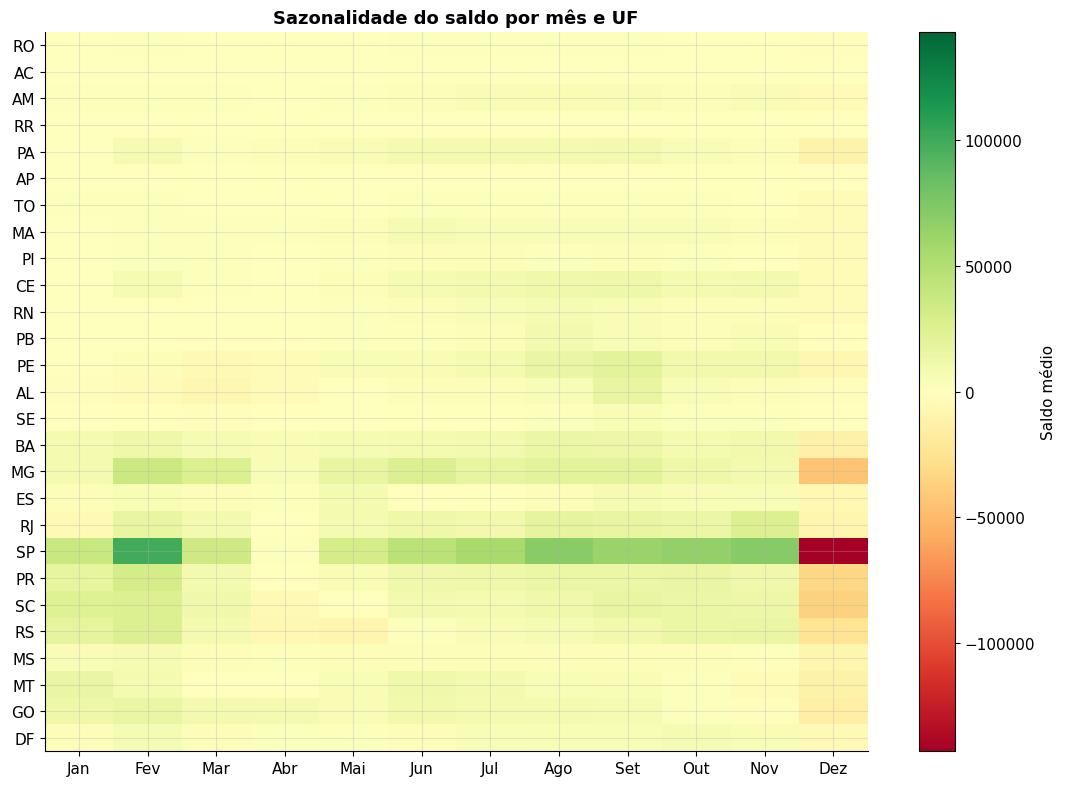

In [11]:
# mapa de calor de sazonalidade (saldo médio por mês × UF)
p = panel.copy(); p["mes"] = p["date"].dt.month
piv = p.groupby(["uf","mes"])["saldo"].mean().unstack().reindex(ordem)
plt.figure(figsize=(11, 8))
import matplotlib.colors as mcolors
vmax = np.nanmax(np.abs(piv.values))
plt.imshow(piv.values, cmap="RdYlGn", aspect="auto",
           norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
plt.colorbar(label="Saldo médio"); plt.yticks(range(len(ordem)), ordem)
plt.xticks(range(12), meses); plt.title("Sazonalidade do saldo por mês e UF")
plt.tight_layout(); plt.show()

## 8. Modelagem e previsão

Para o Brasil e **cada UF** ajustamos três modelos e projetamos até **jun/2027**:

| Modelo | Descrição |
|---|---|
| **SARIMA** | seleção automática (`auto_arima`, sazonalidade m=12), captura tendência+sazonalidade |
| **ETS (Holt-Winters)** | suavização exponencial aditiva com tendência e sazonalidade; IC por simulação |
| **Seasonal Naive** | *baseline* sazonal (repete o último ano); IC pelo erro sazonal in-sample |

A seleção do **melhor modelo** usa o **menor RMSE** em *backtest* (retenção dos últimos
12 meses). Calculamos RMSE, MAE, MASE e sMAPE. Esta etapa ajusta ~84 modelos — pode levar
alguns minutos.

In [12]:
import time
t0 = time.time()
results = {}
diagnostics = {}
series_all = clt.all_series(panel)
for i, (nome, s) in enumerate(series_all.items(), 1):
    results[nome] = clt.forecast_series(s)
    adf = clt.adf_test(s); kp = clt.kpss_test(s); ar = clt.arch_test(s)
    diagnostics[nome] = {
        "adf_p": adf["pvalue"], "adf_stationary": adf["stationary"],
        "kpss_p": kp["pvalue"], "arch_p": ar["pvalue"],
        "heteroscedastic": ar["heteroscedastic"],
        "seasonal_strength": clt.seasonal_strength(s),
    }
    print(f"[{i:>2}/{len(series_all)}] {nome:<7} melhor={results[nome]['best']}")
print(f"\nConcluído em {time.time()-t0:.0f}s")

C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


[ 1/28] Brasil  melhor=Seasonal Naive


C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


[ 2/28] RO      melhor=SARIMA


C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


...

[26/28] MT      melhor=Seasonal Naive


C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


[27/28] GO      melhor=SARIMA


[28/28] DF      melhor=SARIMA

Concluído em 313s


C:\Users\apgomes\CLT-BRASIL\src\clt.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")


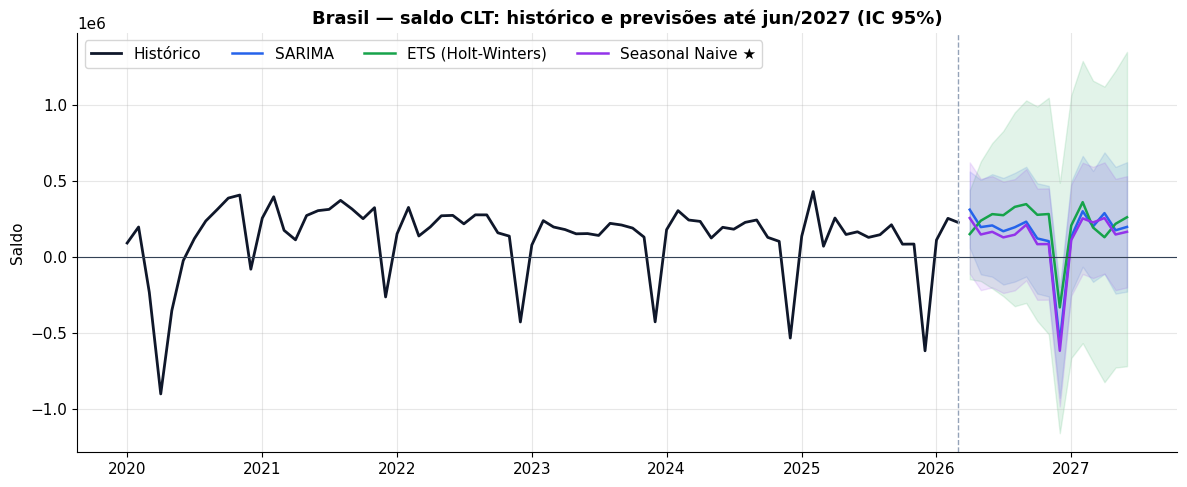

In [13]:
# Brasil — previsões dos três modelos com IC95%
nat = results["Brasil"]
plt.figure(figsize=(12, 5))
h = nat["history"]
plt.plot(h.index, h.values, color="#0f172a", lw=2, label="Histórico")
cores = {"SARIMA":BLUE, "ETS (Holt-Winters)":GREEN, "Seasonal Naive":"#9333ea"}
for mname, m in nat["models"].items():
    if "mean" not in m: continue
    c = cores[mname]
    plt.plot(m["mean"].index, m["mean"].values, color=c, lw=1.8,
             label=f"{mname}{' ★' if mname==nat['best'] else ''}")
    plt.fill_between(m["mean"].index, m["lower"].values, m["upper"].values, color=c, alpha=.12)
plt.axhline(0, color="#334155", lw=.8); plt.axvline(h.index[-1], color="#94a3b8", ls="--", lw=1)
plt.title("Brasil — saldo CLT: histórico e previsões até jun/2027 (IC 95%)")
plt.legend(ncol=4, loc="upper left"); plt.ylabel("Saldo"); plt.tight_layout(); plt.show()

## 9. Métricas, seleção de modelo e diagnóstico de resíduos

Comparação dos modelos para o Brasil (backtest 12m) e verificação de **ruído branco**
nos resíduos do modelo selecionado (Ljung-Box).

In [14]:
def tabela_metricas(res):
    linhas = []
    for mname, m in res["models"].items():
        if "metrics" not in m: continue
        met = m["metrics"]
        linhas.append({"Modelo": mname + (" ★" if mname==res["best"] else ""),
            "RMSE": round(met["RMSE"]), "MAE": round(met["MAE"]),
            "MASE": round(met["MASE"],3), "sMAPE %": round(met["sMAPE"],1),
            "AIC": round(m.get("aic", float('nan')),1) if m.get("aic") else None})
    return pd.DataFrame(linhas)
display(tabela_metricas(nat))

best_model = nat["models"][nat["best"]]
if "order" in best_model:
    print(f"SARIMA selecionado: {best_model['order']} x {best_model['seasonal_order']}")

,Modelo,RMSE,MAE,MASE,sMAPE %,AIC
0,SARIMA,83399,65632,0.544,36.9,1656.2
1,ETS (Holt-Winters),137657,108435,0.899,56.3,1798.0
2,Seasonal Naive ★,80681,62202,0.516,32.0,NaN


## 10. Exportação e relatório HTML autocontido

Salvamos os artefatos processados (previsões e métricas por UF) e geramos o
**relatório HTML interativo e autocontido** (Plotly embutido, sem dependências externas).

In [15]:
# previsões em formato longo
linhas = []
for nome, res in results.items():
    for mname, m in res["models"].items():
        if "mean" not in m: continue
        for dt_, mu in m["mean"].items():
            linhas.append({"serie": nome, "modelo": mname, "data": dt_.date(),
                "previsao": round(mu), "ic_inf": round(m["lower"][dt_]),
                "ic_sup": round(m["upper"][dt_])})
fc_df = pd.DataFrame(linhas)
os.makedirs(clt.PROC, exist_ok=True)
fc_df.to_csv(os.path.join(clt.PROC, "previsoes.csv"), index=False)

# métricas por UF
met_rows = []
for nome, res in results.items():
    b = res["best"]; m = res["models"].get(b, {})
    met = m.get("metrics", {})
    met_rows.append({"serie": nome, "melhor_modelo": b,
        "prev_jun2027": round(m["mean"].iloc[-1]) if "mean" in m else None,
        "ic_inf": round(m["lower"].iloc[-1]) if "lower" in m else None,
        "ic_sup": round(m["upper"].iloc[-1]) if "upper" in m else None,
        "RMSE": round(met.get("RMSE", float('nan'))), "MASE": round(met.get("MASE", float('nan')),3),
        **{k: round(v,3) if isinstance(v,float) else v for k,v in diagnostics[nome].items()}})
met_df = pd.DataFrame(met_rows)
met_df.to_csv(os.path.join(clt.PROC, "metricas_por_uf.csv"), index=False)
print("Artefatos salvos em", clt.PROC)
display(met_df.head(10))

Artefatos salvos em C:\Users\apgomes\CLT-BRASIL\data\processed


,serie,melhor_modelo,prev_jun2027,ic_inf,ic_sup,RMSE,MASE,adf_p,adf_stationary,kpss_p,arch_p,heteroscedastic,seasonal_strength
0,Brasil,Seasonal Naive,166654,-200211,533519,80681,0.516,0.139,False,0.1,0.000,True,0.695
1,RO,SARIMA,984,-1981,3949,440,0.476,0.304,False,0.1,0.009,True,0.669
2,AC,Seasonal Naive,605,-364,1574,393,0.836,0.611,False,0.1,0.066,False,0.799
3,AM,SARIMA,3735,-1054,8524,1587,0.581,0.241,False,0.1,0.000,True,0.576
4,RR,SARIMA,186,-716,1088,476,1.041,0.894,False,0.1,0.065,False,0.612
5,PA,SARIMA,6258,-1308,13825,1831,0.525,0.390,False,0.1,0.000,True,0.849
6,AP,SARIMA,1499,454,2543,315,0.598,0.287,False,0.1,0.004,True,0.695
7,TO,Seasonal Naive,513,-1368,2394,843,0.877,0.735,False,0.1,0.000,True,0.836
8,MA,ETS (Holt-Winters),6462,-351,14114,1367,0.627,0.585,False,0.1,0.011,True,0.778
9,PI,Seasonal Naive,2745,-893,6383,1124,0.696,0.055,False,0.1,0.215,False,0.727


In [16]:
import importlib, report
importlib.reload(report)
uf_results = {u: results[u] for u in [x for r in clt.REGIOES.values() for x in r]}
out = report.build_report(nat, uf_results, panel, diagnostics)
print("Relatório gerado:", out, "(", round(os.path.getsize(out)/1e6,2), "MB )")

Relatório gerado: C:\Users\apgomes\CLT-BRASIL\output\CLT-BRASIL_relatorio.html ( 4.89 MB )


---
### Conclusão

O pipeline recupera a série oficial do Novo CAGED diretamente dos microdados do MTE,
trata e valida os dados, caracteriza tendência, sazonalidade, estacionariedade e
heterocedasticidade, e projeta o saldo de emprego formal **até junho de 2027** para o
Brasil e as 27 UFs, com intervalos de confiança de 95% e seleção de modelo por backtest.
O relatório HTML autocontido (`output/CLT-BRASIL_relatorio.html`) consolida todos os
resultados de forma interativa.